In [1]:
import numpy as np
import pandas as pd
import random
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from skmultilearn.problem_transform import LabelPowerset
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import hamming_loss
from sklearn.metrics import classification_report as classification_report_multiout
from itertools import product

import sys
import math
import shap
import xgboost as xgb

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
P = 'P1'
p = P.lower()

file1 = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\CMacedonia\GR_CMacedonia_WNV_Dataset_P1_2010_2023.csv'
file2 = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\Thessaly\GR_Thessaly_WNV_Dataset_P1_2010_2023.csv'
file3 = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\Thrace\GR_Thrace_WNV_Dataset_P1_2010_2023.csv'
file4 = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\Attica\GR_Attica_WNV_Dataset_P1_2010_2023.csv'

dataset1 = read_data(file1)
dataset2 = read_data(file2)
dataset3 = read_data(file3)
dataset4 = read_data(file4)


dataset1.head()

dataset2.head()

dataset3.head()

dataset4.head()

dataset = pd.concat([dataset1, dataset2, dataset3, dataset4])

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(308, 73)


In [2]:
dataset.head()

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL521,2010,22.217953,40.552111,NaN,NaN,NaN,NaN,6.832007,10.274829,3.389185,-0.323333,1.440741,5.691801,524.456884,381.438272,1144.314815,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12341.159415,1649.062953,10.944444,168.992002,478.965221,174.592727,0.000000,11.398553,6076.767846,845.730815,7.771299,68.692804,549.734952,11.897101,0.000000,39.809207,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,5025.2,5265.4,49,"[0, 0, 6, 36, 7, 0]"
1,EL522,2010,23.139033,40.693632,0.246671,-0.155465,0.054331,-0.054331,7.666022,11.889764,3.442280,-2.889219,3.587031,4.429008,409.388384,361.513021,1084.539062,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8557.094766,2215.429410,6.085938,170.680419,293.945344,182.360495,0.006689,5.870648,5601.498289,830.208992,4.653383,44.047170,208.751660,6.368673,0.075672,10.356983,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,9804.6,10058.8,81,"[0, 0, 11, 50, 20, 0]"
2,EL523,2010,22.762317,41.016275,0.240682,-0.239834,-0.012466,0.012466,6.672266,11.074669,2.269862,-4.752826,1.986957,4.711003,434.944488,279.681159,839.043478,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,10853.608886,1578.911868,6.445652,154.140119,268.106551,177.819913,0.027917,19.739425,4279.770238,1050.253996,4.622839,47.454389,207.798404,11.082440,0.152891,37.062307,5916.0,24162.0,9803.0,39881.0,5598.0,23417.0,11860.0,40875.0,1169.86,5809.2,5920.4,23,"[0, 0, 6, 13, 4, 0]"
3,EL524,2010,22.109782,40.888821,0.242562,-0.053267,0.147196,-0.147196,6.576489,10.600797,2.552180,-3.833409,0.897500,5.741834,528.670447,338.670455,1016.011364,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,31,20,30,12,9,4,4,4,17955.952973,1245.342993,10.465909,143.782989,491.318221,175.099690,0.000000,16.376737,8218.741359,744.858619,9.578411,58.262998,412.742844,15.300984,0.000000,46.596976,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,5025.2,5265.4,57,"[0, 0, 3, 41, 13, 0]"
4,EL525,2010,22.442423,40.269959,NaN,NaN,NaN,NaN,8.062156,11.409259,4.715053,0.756667,4.043333,4.973131,459.127417,375.407407,1126.222222,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,31,36,30,12,12,1,6,7,11735.919071,971.980212,13.400000,134.587334,430.793162,170.687146,0.000000,21.108785,5383.969555,789.936868,8.881544,48.186142,455.707394,9.701413,0.000000,46.416540,10377.0,39695.0,11841.0,61913.0,10120.0,40015.0,14312.0,64447.0,1815.79,5025.2,5265.4,13,"[0, 0, 1, 7, 5, 0]"


In [3]:
dataset['cases_arr'] = dataset['cases_arr'].apply(lambda x: json.loads(x))
dataset['cases_arr'] = dataset['cases_arr'].apply(lambda x: np.array(x))
dataset = convert_multiple_cases_array_weighted(dataset, target_col='cases_arr')
dataset['cases_total'] = dataset['cases_total'].apply(lambda x: 1 if x > 0 else 0)
print(dataset.shape)

(727, 73)


In [4]:
dataset.head()

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL521,2010,22.217953,40.552111,NaN,NaN,NaN,NaN,6.832007,10.274829,3.389185,-0.323333,1.440741,5.691801,524.456884,381.438272,1144.314815,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12341.159415,1649.062953,10.944444,168.992002,478.965221,174.592727,0.000000,11.398553,6076.767846,845.730815,7.771299,68.692804,549.734952,11.897101,0.000000,39.809207,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,5025.2,5265.4,1,"[0, 0, 1, 1, 1, 0]"
1,EL522,2010,23.139033,40.693632,0.246671,-0.155465,0.054331,-0.054331,7.666022,11.889764,3.442280,-2.889219,3.587031,4.429008,409.388384,361.513021,1084.539062,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8557.094766,2215.429410,6.085938,170.680419,293.945344,182.360495,0.006689,5.870648,5601.498289,830.208992,4.653383,44.047170,208.751660,6.368673,0.075672,10.356983,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,9804.6,10058.8,1,"[0, 0, 1, 1, 1, 0]"
2,EL523,2010,22.762317,41.016275,0.240682,-0.239834,-0.012466,0.012466,6.672266,11.074669,2.269862,-4.752826,1.986957,4.711003,434.944488,279.681159,839.043478,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,10853.608886,1578.911868,6.445652,154.140119,268.106551,177.819913,0.027917,19.739425,4279.770238,1050.253996,4.622839,47.454389,207.798404,11.082440,0.152891,37.062307,5916.0,24162.0,9803.0,39881.0,5598.0,23417.0,11860.0,40875.0,1169.86,5809.2,5920.4,1,"[0, 0, 1, 1, 1, 0]"
3,EL524,2010,22.109782,40.888821,0.242562,-0.053267,0.147196,-0.147196,6.576489,10.600797,2.552180,-3.833409,0.897500,5.741834,528.670447,338.670455,1016.011364,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,31,20,30,12,9,4,4,4,17955.952973,1245.342993,10.465909,143.782989,491.318221,175.099690,0.000000,16.376737,8218.741359,744.858619,9.578411,58.262998,412.742844,15.300984,0.000000,46.596976,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,5025.2,5265.4,1,"[0, 0, 1, 1, 1, 0]"
4,EL525,2010,22.442423,40.269959,NaN,NaN,NaN,NaN,8.062156,11.409259,4.715053,0.756667,4.043333,4.973131,459.127417,375.407407,1126.222222,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,31,36,30,12,12,1,6,7,11735.919071,971.980212,13.400000,134.587334,430.793162,170.687146,0.000000,21.108785,5383.969555,789.936868,8.881544,48.186142,455.707394,9.701413,0.000000,46.416540,10377.0,39695.0,11841.0,61913.0,10120.0,40015.0,14312.0,64447.0,1815.79,5025.2,5265.4,1,"[0, 0, 1, 1, 1, 0]"


In [5]:
X = dataset.drop(columns=['cases_total','cases_arr'])
y = dataset['cases_arr']
s = dataset['cases_total']

In [6]:
n_folds = 7
#k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)
k_fold = KFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [7]:
features_to_remove = ['x', 'y', 'year', 'lc_prop1', 'lc_prop3', 'lc_type1', 'lc_type3', 'lc_type4', 'lc_type5']
feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names)

Index(['ndvi_p1', 'ndwi_p1', 'ndmi_p1', 'ndbi_p1', 'lst_mean_p1',
       'lst_day_mean_p1', 'lst_night_mean_p1', 'lst_min_p1', 'lst_max_p1',
       'prec_mean_p1', 'prec_acc_p1', 'mosq_mean_p1', 'mosq_sum_p1', 'bio1',
       'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'lc_prop2', 'lc_type2', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std',
       'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std',
       'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std',
       'males_lt15', 'males_15t64', 'males_gt65', 'males_total',
       'females_lt15', 'females_15t64', 'females_gt65', 'females_total',
       'mio_eur', 'l_total', 'unl_total'],
      dtype='object')

In [8]:
## XGBoost Model Parameters

params = {
    "objective": "binary:logistic",
    "multi_strategy": "multi_output_tree", 
    "colsample_bytree": 1.0, 
    "device": "cpu", 
    "eval_metric": "logloss",
    "gamma": 0.5, 
    "learning_rate": 0.3, 
    "max_depth": 4, 
    "min_child_weight": 5, 
    "n_estimators": 100, 
    "reg_alpha": 0.5, 
    "scale_pos_weight": 1, 
    "subsample": 1.0, 
    "tree_method": "hist"

    }

In [9]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []
#shap_list = []

for train_idx, test_idx in k_fold.split(X, s):
    print(f'Fold: {fold_counter+1}/{n_folds}')
    X_train = X.iloc[train_idx].select_dtypes(exclude=['object']).drop(columns = features_to_remove)
    X_test = X.iloc[test_idx].select_dtypes(exclude=['object']).drop(columns = features_to_remove)

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    print(f"Training set 0/1 Ratio: {(dataset.iloc[train_idx]['cases_total'].value_counts().get(0) / dataset.iloc[train_idx]['cases_total'].value_counts().get(1)):.2f}")
    print(f"Test set 0/1 Ratio: {(dataset.iloc[test_idx]['cases_total'].value_counts().get(0) / dataset.iloc[test_idx]['cases_total'].value_counts().get(1)):.2f}")
    
    scaler = MinMaxScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
            
    imputer = KNNImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train_scaled)
    X_test_imputed = imputer.transform(X_test_scaled)

    y_train_np = np.stack(y_train.to_numpy())
    y_test_np = np.stack(y_test.to_numpy())

    model = xgb.XGBClassifier(**params)   
    trained_model = model.fit(X_train_imputed, y_train_np)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    # explainer = shap.KernelExplainer(trained_model.predict_proba, X_train_imputed, link = 'logit')
    # explainer = shap.KernelExplainer(trained_model.predict_proba, shap.kmeans(X_train_imputed, 20), link = 'logit')
    # shap_values = explainer.shap_values(X_train_imputed)

    y_train_list.append(y_train_np)
    y_test_list.append(y_test_np)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    #shap_list.append(shap_values)
    fold_counter += 1

Fold: 1/7
Training set 0/1 Ratio: 0.32
Test set 0/1 Ratio: 0.32
Fold: 2/7
Training set 0/1 Ratio: 0.31
Test set 0/1 Ratio: 0.37
Fold: 3/7
Training set 0/1 Ratio: 0.34
Test set 0/1 Ratio: 0.22
Fold: 4/7
Training set 0/1 Ratio: 0.34
Test set 0/1 Ratio: 0.24
Fold: 5/7
Training set 0/1 Ratio: 0.32
Test set 0/1 Ratio: 0.32
Fold: 6/7
Training set 0/1 Ratio: 0.30
Test set 0/1 Ratio: 0.49
Fold: 7/7
Training set 0/1 Ratio: 0.32
Test set 0/1 Ratio: 0.34


In [10]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

In [11]:
train_loss = log_loss_vector(y_train_true, y_train_proba)
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss_vector(y_test_true, y_test_proba)
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.0409
Test Loss: 0.1076


In [12]:
classification_thresholds = optimal_threashold_fbeta_vector(y_train_proba, y_train_true, beta = 2, round_factor = 2)
print(classification_thresholds)

[0.08 0.16 0.3  0.43 0.44 0.18]


In [13]:
classification_thresholds_test = optimal_threashold_fbeta_vector(y_test_proba, y_test_true, beta = 2, round_factor = 2)
print(classification_thresholds_test)

[0.03 0.1  0.35 0.67 0.62 0.3 ]


In [14]:
y_train_pred = np.where(y_train_proba < classification_thresholds, 0, 1)
y_test_pred = np.where(y_test_proba < classification_thresholds, 0, 1)

In [15]:
y_train_pred_with_test = np.where(y_train_proba < classification_thresholds_test, 0, 1)
y_test_pred_with_test = np.where(y_test_proba < classification_thresholds_test, 0, 1)

In [16]:
hm_loss = hamming_loss(y_test_true, y_test_pred)
print(f"Hamming Loss: {hm_loss}")

Hamming Loss: 0.039889958734525444


In [17]:
print(classification_report_multiout(y_test_true, y_test_pred, output_dict=False, target_names=['May', 'June', 'July', 'August', 'September', 'October']))

              precision    recall  f1-score   support

         May       1.00      0.25      0.40         4
        June       1.00      0.80      0.89        20
        July       0.92      0.98      0.95       276
      August       0.91      0.99      0.95       522
   September       0.92      0.98      0.95       455
     October       0.86      0.93      0.89       122

   micro avg       0.91      0.97      0.94      1399
   macro avg       0.93      0.82      0.84      1399
weighted avg       0.91      0.97      0.94      1399
 samples avg       0.72      0.73      0.72      1399



In [18]:
print(classification_report_multiout(y_test_true, y_test_pred_with_test, output_dict=False, target_names=['May', 'June', 'July', 'August', 'September', 'October']))

              precision    recall  f1-score   support

         May       0.17      1.00      0.30         4
        June       0.83      1.00      0.91        20
        July       0.94      0.98      0.96       276
      August       0.95      0.97      0.96       522
   September       0.95      0.97      0.96       455
     October       0.93      0.92      0.92       122

   micro avg       0.94      0.97      0.95      1399
   macro avg       0.80      0.97      0.84      1399
weighted avg       0.95      0.97      0.96      1399
 samples avg       0.72      0.72      0.72      1399



In [19]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''
labels = [0,1,2,3,4,5]

cm = multilabel_confusion_matrix(y_test_true, y_test_pred, labels=labels)

print(cm)
print('\n')
print(np.sum(cm, axis=0))

[[[723   0]
  [  3   1]]

 [[707   0]
  [  4  16]]

 [[426  25]
  [  6 270]]

 [[153  52]
  [  6 516]]

 [[232  40]
  [ 11 444]]

 [[587  18]
  [  9 113]]]


[[2828  135]
 [  39 1360]]


In [20]:
cm = multilabel_confusion_matrix(y_test_true, y_test_pred_with_test, labels=labels)

print(cm)
print('\n')
print(np.sum(cm, axis=0))

[[[704  19]
  [  0   4]]

 [[703   4]
  [  0  20]]

 [[435  16]
  [  6 270]]

 [[181  24]
  [ 14 508]]

 [[250  22]
  [ 14 441]]

 [[596   9]
  [ 10 112]]]


[[2869   94]
 [  44 1355]]


In [21]:
X_train = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove)
y_train = y

In [21]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)

y_train_np = np.stack(y_train.to_numpy())

model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train_np)

explainer = shap.KernelExplainer(trained_model.predict_proba, X_train_imputed, link = 'logit')
# explainer = shap.KernelExplainer(trained_model.predict_proba, shap.kmeans(X_train_imputed, 20), link = 'logit')
shap_values = explainer.shap_values(X_train_imputed)

Using 727 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 727/727 [54:38<00:00,  4.51s/it]


In [25]:
X_train

,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop2,lc_type2,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total
0,NaN,NaN,NaN,NaN,6.832007,10.274829,3.389185,-0.323333,1.440741,5.691801,524.456884,381.438272,1144.314815,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,36,12,12341.159415,1649.062953,10.944444,168.992002,478.965221,174.592727,0.000000,11.398553,6076.767846,845.730815,7.771299,68.692804,549.734952,11.897101,0.000000,39.809207,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,5025.2,5265.4
1,0.246671,-0.155465,0.054331,-0.054331,7.666022,11.889764,3.442280,-2.889219,3.587031,4.429008,409.388384,361.513021,1084.539062,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,30,10,8557.094766,2215.429410,6.085938,170.680419,293.945344,182.360495,0.006689,5.870648,5601.498289,830.208992,4.653383,44.047170,208.751660,6.368673,0.075672,10.356983,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,9804.6,10058.8
2,0.240682,-0.239834,-0.012466,0.012466,6.672266,11.074669,2.269862,-4.752826,1.986957,4.711003,434.944488,279.681159,839.043478,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,36,12,10853.608886,1578.911868,6.445652,154.140119,268.106551,177.819913,0.027917,19.739425,4279.770238,1050.253996,4.622839,47.454389,207.798404,11.082440,0.152891,37.062307,5916.0,24162.0,9803.0,39881.0,5598.0,23417.0,11860.0,40875.0,1169.86,5809.2,5920.4
3,0.242562,-0.053267,0.147196,-0.147196,6.576489,10.600797,2.552180,-3.833409,0.897500,5.741834,528.670447,338.670455,1016.011364,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,20,9,17955.952973,1245.342993,10.465909,143.782989,491.318221,175.099690,0.000000,16.376737,8218.741359,744.858619,9.578411,58.262998,412.742844,15.300984,0.000000,46.596976,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,5025.2,5265.4
4,NaN,NaN,NaN,NaN,8.062156,11.409259,4.715053,0.756667,4.043333,4.973131,459.127417,375.407407,1126.222222,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,36,12,11735.919071,971.980212,13.400000,134.587334,430.793162,170.687146,0.000000,21.108785,5383.969555,789.936868,8.881544,48.186142,455.707394,9.701413,0.000000,46.416540,10377.0,39695.0,11841.0,61913.0,10120.0,40015.0,14312.0,64447.0,1815.79,5025.2,5265.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
722,0.224630,0.148014,0.335510,-0.335510,7.939797,12.116715,3.762879,-4.363692,5.677025,2.561517,234.933898,551.647551,1654.942652,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1367.0,275.0,22.0,62.742437,548.0,158.0,158.0,377.0,36,12,20304.616706,1427.950859,8.598566,159.791362,382.740079,180.565314,0.000000,54.763716,10522.041881,966.962784,8.968578,54.239563,359.23

In [23]:
shap_values_path = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\ValuesShap\GR_P1_2010-2023_Shapely_Values_vectorleaf.npz'

# np.savez(shap_values_path, *shap_values)

shap_values = []
loaded_shap_values = np.load(shap_values_path)

for key in loaded_shap_values.keys():
    shap_values.append(loaded_shap_values[key])

In [26]:
shap_values[0].shape

(727, 61)

In [ ]:
enviromental = ['ndvi_p1','ndwi_p1','ndmi_p1','ndbi_p1']
climate = ['lst_mean_p1', 'lst_day_mean_p1', 'lst_night_mean_p1', 'lst_min_p1', 'lst_max_p1', 'prec_mean_p1', 'prec_acc_p1',]
vectors = ['mosq_mean_p1', 'mosq_sum_p1',]
bioclimatic = ['bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']
landuse = ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
geomorphological = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std',]
demographic = ['males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_total',]
economics = ['mio_eur', 'l_total', 'unl_total',]

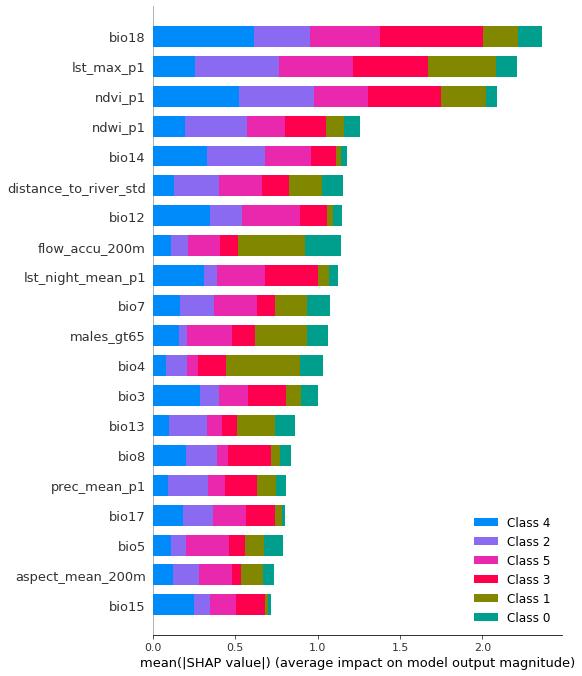

In [26]:
shap.summary_plot(shap_values = shap_values, features = feature_names)

In [27]:
shap_values_total = np.concatenate(shap_values, axis=0)

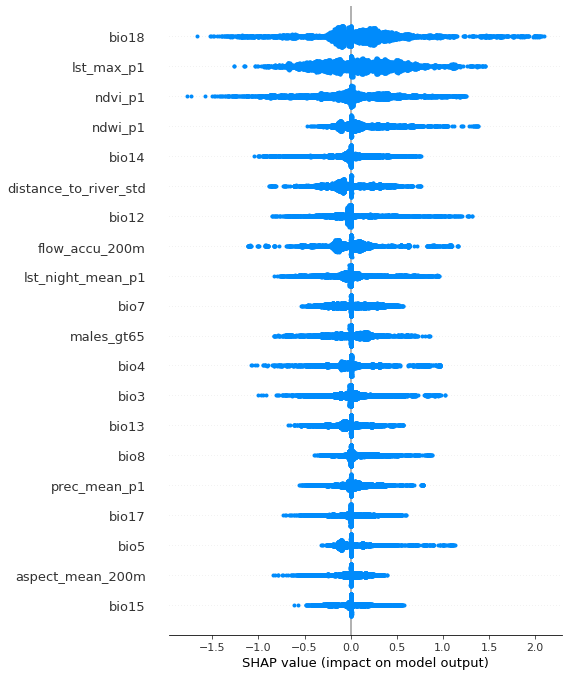

In [28]:
shap.summary_plot(shap_values = shap_values_total, features = feature_names)

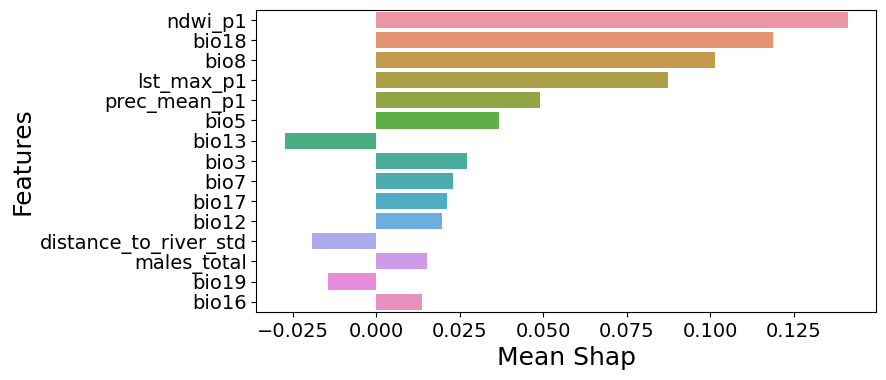

In [29]:
mean_shap = shap_values_total.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

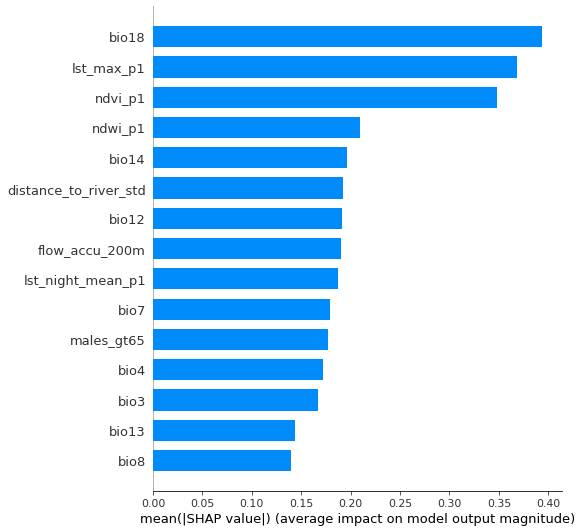

In [30]:
shap.summary_plot(shap_values_total, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

,features,weights
3,bioclimatic,0.448243
0,enviromental,0.160458
1,climate,0.159040
5,geomorphological,0.054091
6,demographic,0.050079
7,economics,0.012639
2,vectors,0.002575
4,landuse,0.002517


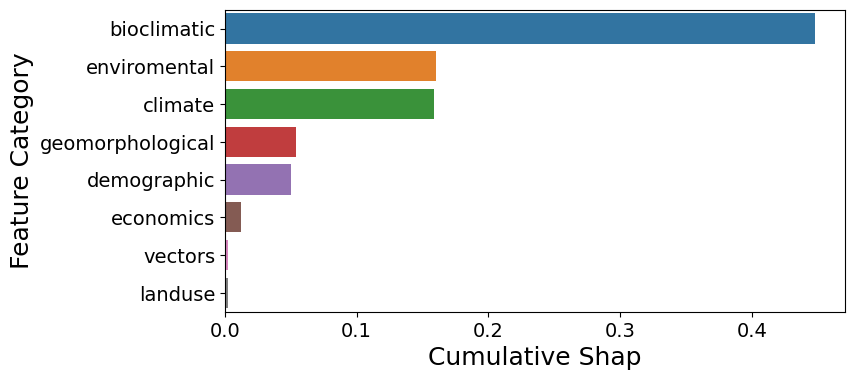

In [31]:
df_enviromental = shaps.loc[shaps['features'].isin(enviromental)].drop(columns=['weights'])
df_climate = shaps.loc[shaps['features'].isin(climate)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_landuse = shaps.loc[shaps['features'].isin(landuse)].drop(columns=['weights'])
df_geomorphological = shaps.loc[shaps['features'].isin(geomorphological)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_economics = shaps.loc[shaps['features'].isin(economics)].drop(columns=['weights'])

categories = {'Category': ['enviromental', 'climate', 'vectors', 'bioclimatic', 'landuse', 'geomorphological', 'demographic', 'economics'], 
              'Mean_Shap': [df_enviromental.weights_abs.sum(),df_climate.weights_abs.sum(),df_vectors.weights_abs.sum(),
                            df_bioclimatic.weights_abs.sum(),df_landuse.weights_abs.sum(),df_geomorphological.weights_abs.sum(),
                            df_demographic.weights_abs.sum(), df_economics.weights_abs.sum()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,8)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Cumulative Shap', figure_size = (8, 4))

,features,weights
0,enviromental,0.040115
3,bioclimatic,0.023592
1,climate,0.022720
6,demographic,0.006260
7,economics,0.004213
5,geomorphological,0.003381
2,vectors,0.001287
4,landuse,0.001258


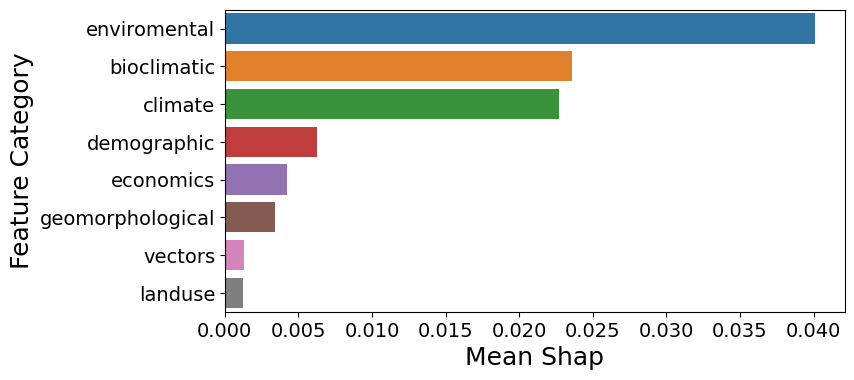

In [32]:
categories = {'Category': ['enviromental', 'climate', 'vectors', 'bioclimatic', 'landuse', 'geomorphological', 'demographic', 'economics'], 
              'Mean_Shap': [df_enviromental.weights_abs.mean(),df_climate.weights_abs.mean(),df_vectors.weights_abs.mean(),
                            df_bioclimatic.weights_abs.mean(),df_landuse.weights_abs.mean(),df_geomorphological.weights_abs.mean(),
                            df_demographic.weights_abs.mean(), df_economics.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,8)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))